# Évaluation CL — EWC Online + MLP — Dataset 2 Equipment Monitoring — by_equipment

| Champ | Valeur |
|-------|--------|
| **Modèle** | EWC Online + MLP (705 paramètres, input_dim=4, hidden=[32, 16]) |
| **Dataset** | equipment_anomaly_data.csv — 7 672 échantillons |
| **Scénario** | by_equipment : Pump → Turbine → Compressor (3 tâches) |
| **Expérience** | exp_001 — voir experiments/exp_001_ewc_monitoring_by_equipment/config_snapshot.yaml |
| **Sprint** | 7 — S7-02 |

> **Modèle supervisé** : EWC reçoit les labels à l'entraînement.  
> Sortie = probabilité de défaut ŷ ∈ [0, 1] (sigmoid).  
> RAM = 1 171 B — meilleure empreinte mémoire parmi les modèles supervisés.  
> Stratégie CL : régularisation EWC Online (λ=1000, γ=0.9) — aucun buffer de replay.

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/monitoring_by_equipment/ewc.ipynb \
    --output /tmp/ewc_executed.ipynb --ExecutePreprocessor.timeout=300
```

In [1]:
# Section 1 — Setup & imports
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim
from IPython.display import Image, Markdown, display

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "monitoring_by_equipment":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_accuracy_matrix,
    plot_confusion_matrix_grid,
    plot_forgetting_curve,
    plot_roc_curves_per_task,
    save_figure,
)
from src.evaluation.feature_space_plots import (
    fit_pca2d,
    plot_feature_space_2d,
)

# --- Chemins ---
EXP_DIR     = REPO_ROOT / "experiments/exp_001_ewc_monitoring_by_equipment/results"
FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/ewc/monitoring/by_equipment"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH        = REPO_ROOT / "data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv"
NORMALIZER_PATH = REPO_ROOT / "configs/monitoring_normalizer.yaml"

# --- Constantes ---
TASK_NAMES    = ["Pump", "Turbine", "Compressor"]
MODEL_NAME    = "EWC"
DATA_AVAILABLE = CSV_PATH.exists()

print(f"REPO_ROOT      : {REPO_ROOT}")
print(f"EXP_DIR        : {EXP_DIR}")
print(f"FIGURES_DIR    : {FIGURES_DIR}")
print(f"CSV disponible : {DATA_AVAILABLE}")
print(f"Date exécution : {datetime.now():%Y-%m-%d %H:%M}")

if not DATA_AVAILABLE:
    display(Markdown(
        "> ⚠️ **CSV absent** — Sections 5, 6, 7, 8 en mode dégradé (données synthétiques). "
        "Placer `equipment_anomaly_data.csv` dans `data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/` pour le mode complet."
    ))

REPO_ROOT      : /home/leonard/Documents/ENAC/cl-embedded
EXP_DIR        : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_001_ewc_monitoring_by_equipment/results
FIGURES_DIR    : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/ewc/monitoring/by_equipment
CSV disponible : True
Date exécution : 2026-04-22 13:27


In [2]:
# Section 2 — Chargement des résultats exp_001

metrics_path    = EXP_DIR / "metrics.json"
acc_matrix_path = EXP_DIR / "acc_matrix_ewc.npy"

metrics    = json.loads(metrics_path.read_text())
acc_matrix = np.load(acc_matrix_path, allow_pickle=True)

# Extraire les métriques EWC depuis la structure imbriquée
cl  = metrics["cl_metrics"]["ewc"]
mem = metrics["cl_metrics"]["memory"]["forward"]

# Reconstruire la matrice acc numpy (remplacement null → NaN)
acc_matrix_json = np.array(
    [[v if v is not None else np.nan for v in row] for row in cl["acc_matrix"]],
    dtype=float,
)

print("=" * 55)
print(f"  Modèle         : EWC Online + MLP")
print(f"  AA             = {cl['aa']:.4f}")
print(f"  AF             = {cl['af']:.4f}")
print(f"  BWT            = {cl['bwt']:.4f}")
print(f"  FWT            = {cl['fwt']:.4f}")
print(f"  Forgetting/tâche: {[round(v, 4) for v in cl['forgetting_per_task']]}")
print(f"  RAM peak       = {mem['ram_peak_bytes']} B ({mem['ram_peak_bytes']/1024:.2f} Ko)")
print(f"  Latence        = {mem['inference_latency_ms']:.5f} ms")
print(f"  n_params       = {mem['n_params']}")
print(f"  Budget 64 Ko   : {mem['within_budget_64ko']}")
print("=" * 55)
print("\nMatrice acc (3×3) :")
print(acc_matrix_json)

  Modèle         : EWC Online + MLP
  AA             = 0.9824
  AF             = 0.0010
  BWT            = 0.0000
  FWT            = 0.0000
  Forgetting/tâche: [0.0, 0.0019]
  RAM peak       = 1171 B (1.14 Ko)
  Latence        = 0.03580 ms
  n_params       = 705
  Budget 64 Ko   : True

Matrice acc (3×3) :
[[0.97633136        nan        nan]
 [0.97633136 0.98440546        nan]
 [0.97830375 0.98245614 0.98640777]]


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/ewc/monitoring/by_equipment/acc_matrix.png


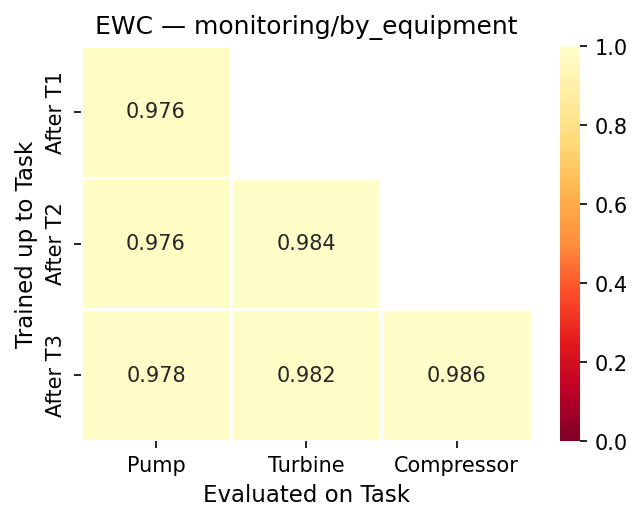

In [3]:
# Section 3 — Matrice d'accuracy (heatmap)
# acc_matrix[i, j] = accuracy sur tâche j après entraînement sur tâche i
# Triangle supérieur = NaN (tâche pas encore vue)
# Diagonale = perf immédiate post-training, sous-diagonale = oubli

fig = plot_accuracy_matrix(
    acc_matrix_json,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — monitoring/by_equipment",
)
save_figure(fig, FIGURES_DIR / "acc_matrix.png")
display(Image(str(FIGURES_DIR / "acc_matrix.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/ewc/monitoring/by_equipment/forgetting_curve.png


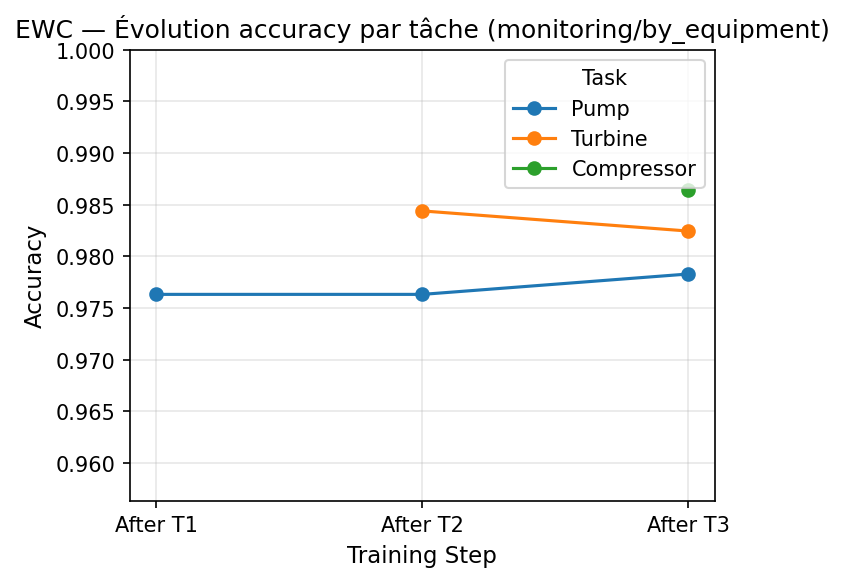

In [4]:
# Section 4 — Courbe d'oubli par tâche
# AF ≈ 0.0010 → courbe quasi-plate : caractéristique d'EWC bien calibré (λ=1000)
# La régularisation Fisher préserve les paramètres critiques des tâches précédentes

fig = plot_forgetting_curve(
    acc_matrix_json,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — Évolution accuracy par tâche (monitoring/by_equipment)",
)
save_figure(fig, FIGURES_DIR / "forgetting_curve.png")
display(Image(str(FIGURES_DIR / "forgetting_curve.png")))

In [5]:
# Section 5 — Rejeu du scénario CL (collecte preds_dict + proba_dict)
# Reproduit exactement la config exp_001 : seed=42, epochs=10/task, SGD lr=0.01,
# λ=1000, γ=0.9, n_fisher_samples=200, hidden=[32,16], dropout=0.2
# Nécessaire pour les matrices de confusion (S6), les courbes ROC (S7) et la PCA (S8)

preds_dict  = {}  # (i, j) → (y_true, y_pred_binary)
proba_dict  = {}  # (i, j) → sigmoid outputs float32  (pour ROC)
X_tests_raw = []  # [N_val, 4] par tâche — pour la viz PCA
y_tests_raw = []  # [N_val] par tâche

if DATA_AVAILABLE:
    from src.data.monitoring_dataset import get_cl_dataloaders
    from src.models.ewc import EWCMlpClassifier
    from src.models.ewc.fisher import compute_fisher_diagonal, update_fisher_online
    from src.utils.reproducibility import set_seed

    set_seed(42)

    tasks = get_cl_dataloaders(
        csv_path=CSV_PATH,
        normalizer_path=NORMALIZER_PATH,
        batch_size=32,
        seed=42,
    )

    # Extraire les données de validation en numpy une seule fois
    for t in tasks:
        X_v = np.concatenate([b[0].numpy() for b in t["val_loader"]])
        y_v = np.concatenate([b[1].numpy().flatten() for b in t["val_loader"]])
        X_tests_raw.append(X_v)
        y_tests_raw.append(y_v)

    # Instancier le modèle EWC (même config que exp_001)
    model = EWCMlpClassifier(input_dim=4, hidden_dims=[32, 16], dropout=0.2)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    fisher     = None
    theta_star = None
    EWC_LAMBDA  = 1000
    EWC_GAMMA   = 0.9
    N_FISHER    = 200
    EPOCHS      = 10

    for i, task in enumerate(tasks):
        domain = task.get("domain", f"Tâche {task['task_id']}")
        print(f"\n--- Tâche {i + 1}/3 : {domain} ---")

        # Entraînement EWC sur la tâche courante
        model.train()
        for epoch in range(EPOCHS):
            losses = []
            for x, y in task["train_loader"]:
                optimizer.zero_grad()
                loss = model.ewc_loss(x, y, fisher, theta_star, EWC_LAMBDA)
                loss.backward()
                optimizer.step()
                losses.append(loss.item())
            if (epoch + 1) % 5 == 0:
                print(f"  Epoch {epoch+1:2d}/{EPOCHS} | Loss: {np.mean(losses):.4f}")

        # Snapshot θ* + mise à jour Fisher Online
        theta_star = model.get_theta_star()
        new_fisher = compute_fisher_diagonal(model, task["train_loader"], "cpu", n_samples=N_FISHER)
        fisher = update_fisher_online(fisher, new_fisher, gamma=EWC_GAMMA)
        print(f"  Fisher mis à jour (γ={EWC_GAMMA})")

        # Évaluation sur toutes les tâches vues jusqu'à i → collecte preds + probas
        model.eval()
        with torch.no_grad():
            for j in range(i + 1):
                X_j = torch.from_numpy(X_tests_raw[j]).float()
                probas = model(X_j).numpy().flatten()
                y_pred = (probas >= 0.5).astype(float)
                preds_dict[(i, j)]  = (y_tests_raw[j], y_pred)
                proba_dict[(i, j)]  = probas.astype(np.float32)
                acc = (y_tests_raw[j] == y_pred).mean()
                print(f"  preds_dict[({i},{j})] → N={len(y_tests_raw[j])}, acc={acc:.4f}")

    print(f"\nScénario CL rejoué — {len(preds_dict)} évaluations collectées")

else:
    display(Markdown("> ⚠️ **Mode dégradé** — CSV absent. preds_dict synthétique depuis acc_matrix."))

    # Reconstruction approchée depuis acc_matrix_json (50% normal / 50% faulty)
    N_SYNTH = 500
    rng = np.random.default_rng(42)
    y_synth = np.concatenate([np.zeros(N_SYNTH // 2), np.ones(N_SYNTH // 2)])

    for i in range(3):
        for j in range(i + 1):
            acc_ij = acc_matrix_json[i, j]
            noise = rng.normal(0, 0.1, N_SYNTH)
            probas_synth = np.where(y_synth == 1, 0.75 + noise, 0.25 + noise).clip(0, 1)
            y_pred_synth = (probas_synth >= 0.5).astype(float)
            preds_dict[(i, j)]  = (y_synth.copy(), y_pred_synth)
            proba_dict[(i, j)]  = probas_synth.astype(np.float32)

    print("preds_dict synthétique créé (mode dégradé — CSV absent)")

✅ Seed fixé à 42
✅ Seed fixé à 42

--- Tâche 1/3 : Pump ---


/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Epoch  5/10 | Loss: 0.1392
  Epoch 10/10 | Loss: 0.1013
  Fisher mis à jour (γ=0.9)
  preds_dict[(0,0)] → N=507, acc=0.9783

--- Tâche 2/3 : Turbine ---
  Epoch  5/10 | Loss: 0.0945
  Epoch 10/10 | Loss: 0.0905
  Fisher mis à jour (γ=0.9)
  preds_dict[(1,0)] → N=507, acc=0.9783
  preds_dict[(1,1)] → N=513, acc=0.9786

--- Tâche 3/3 : Compressor ---
  Epoch  5/10 | Loss: 0.0777
  Epoch 10/10 | Loss: 0.0727
  Fisher mis à jour (γ=0.9)
  preds_dict[(2,0)] → N=507, acc=0.9783
  preds_dict[(2,1)] → N=513, acc=0.9805
  preds_dict[(2,2)] → N=515, acc=0.9825

Scénario CL rejoué — 6 évaluations collectées


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/ewc/monitoring/by_equipment/confusion_matrix_grid.png


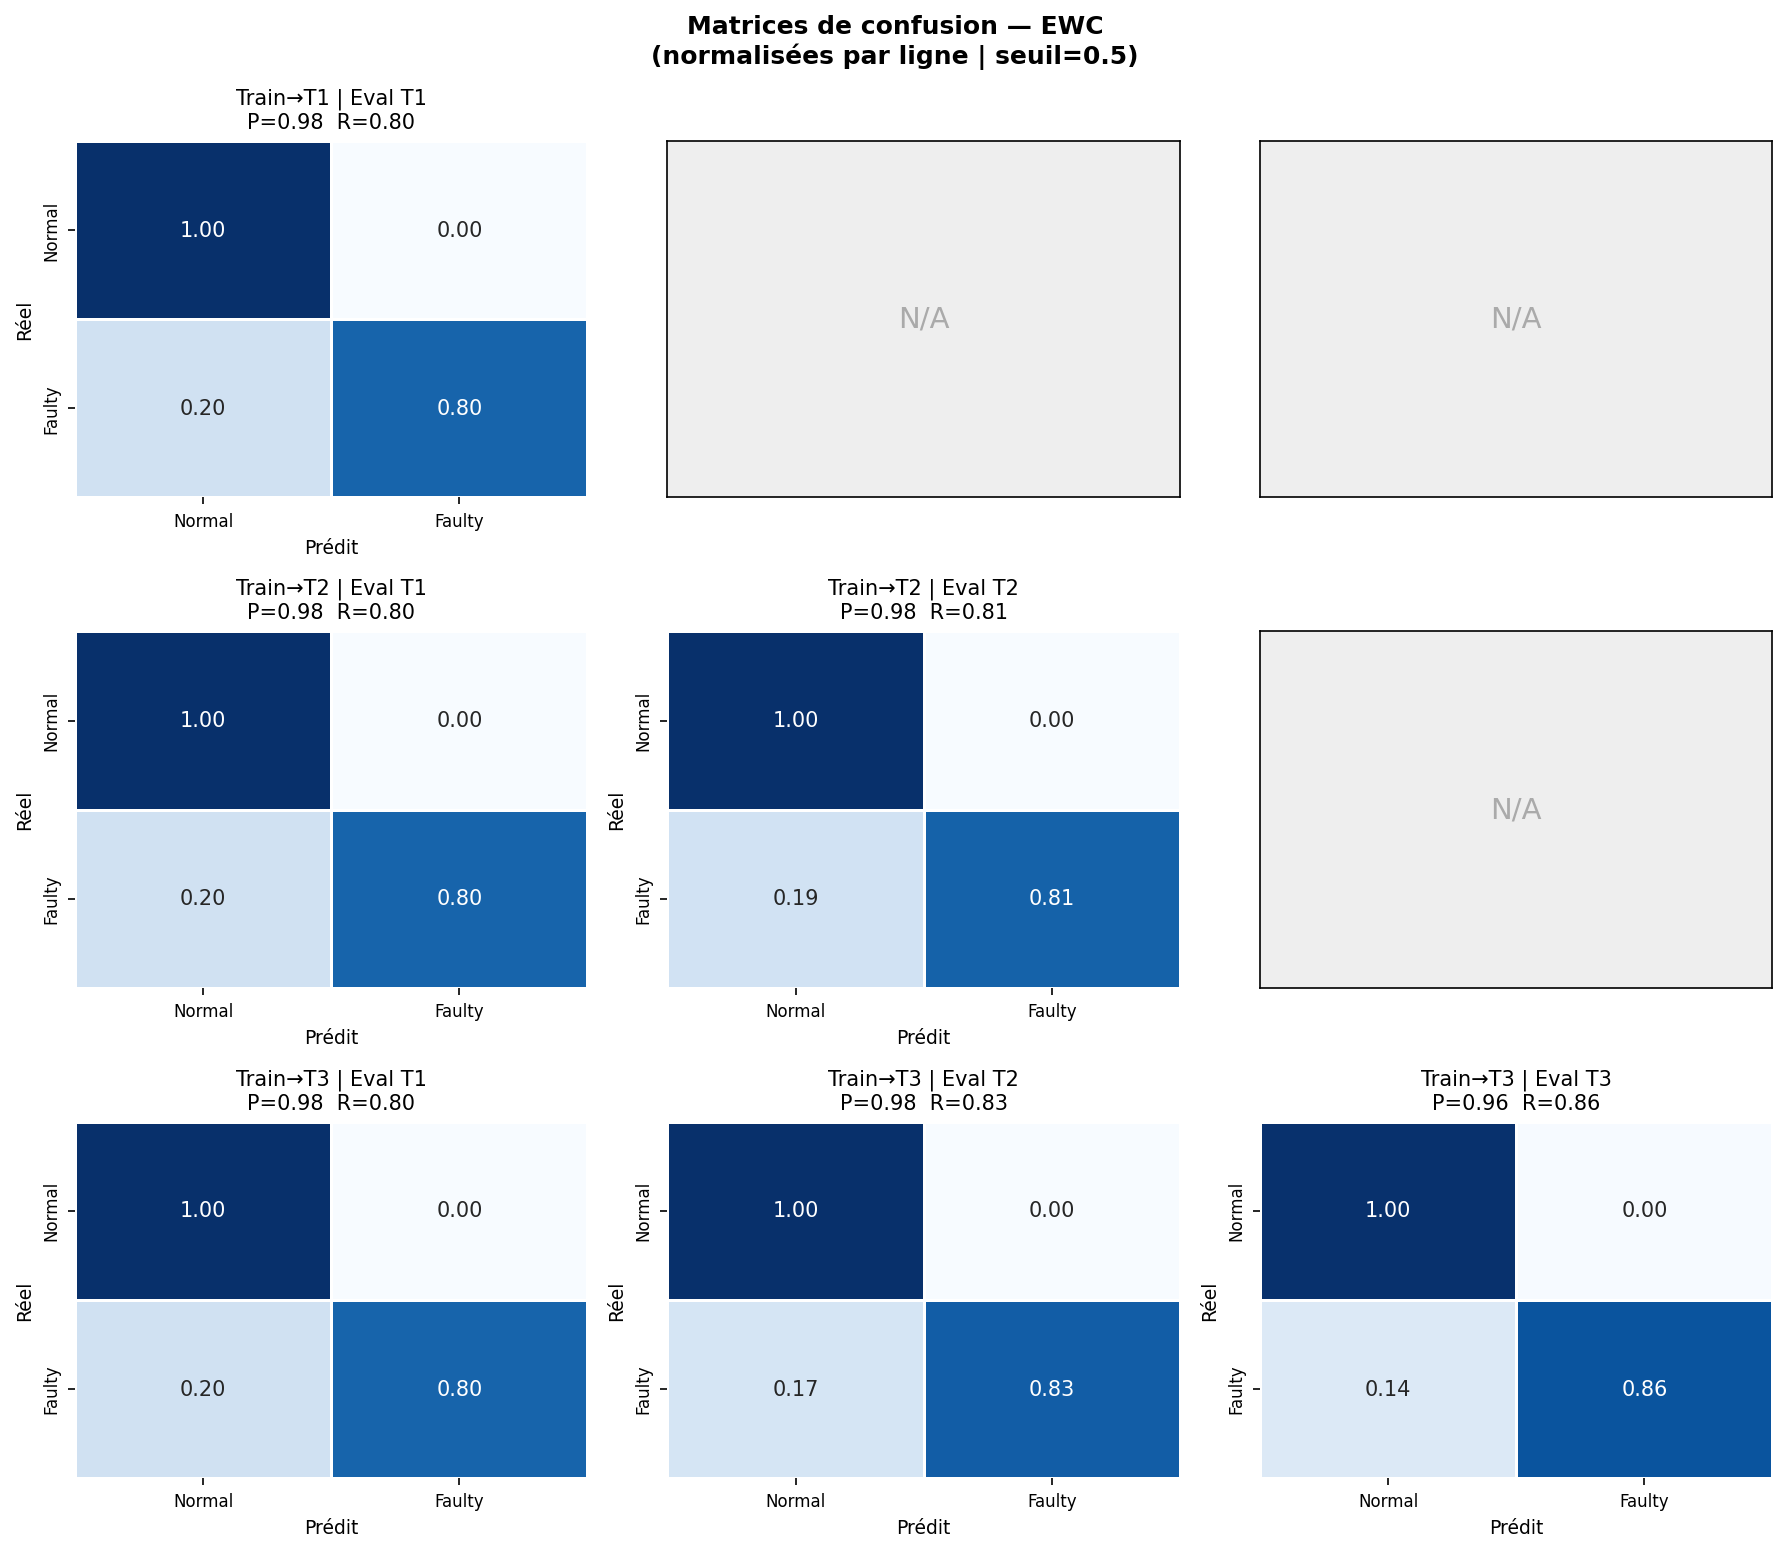

In [6]:
# Section 6 — Matrices de confusion par tâche (grille 3×3)
# Ligne i = état du modèle après entraînement sur tâche i
# Colonne j = évaluation sur tâche j
# Cellule (i,j) avec j > i = grisée (tâche pas encore vue)
# Normalisées par ligne (recall par classe)

fig = plot_confusion_matrix_grid(
    preds_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
    threshold=0.5,
)
save_figure(fig, FIGURES_DIR / "confusion_matrix_grid.png")
display(Image(str(FIGURES_DIR / "confusion_matrix_grid.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/ewc/monitoring/by_equipment/confusion_matrix_grid_raw.png


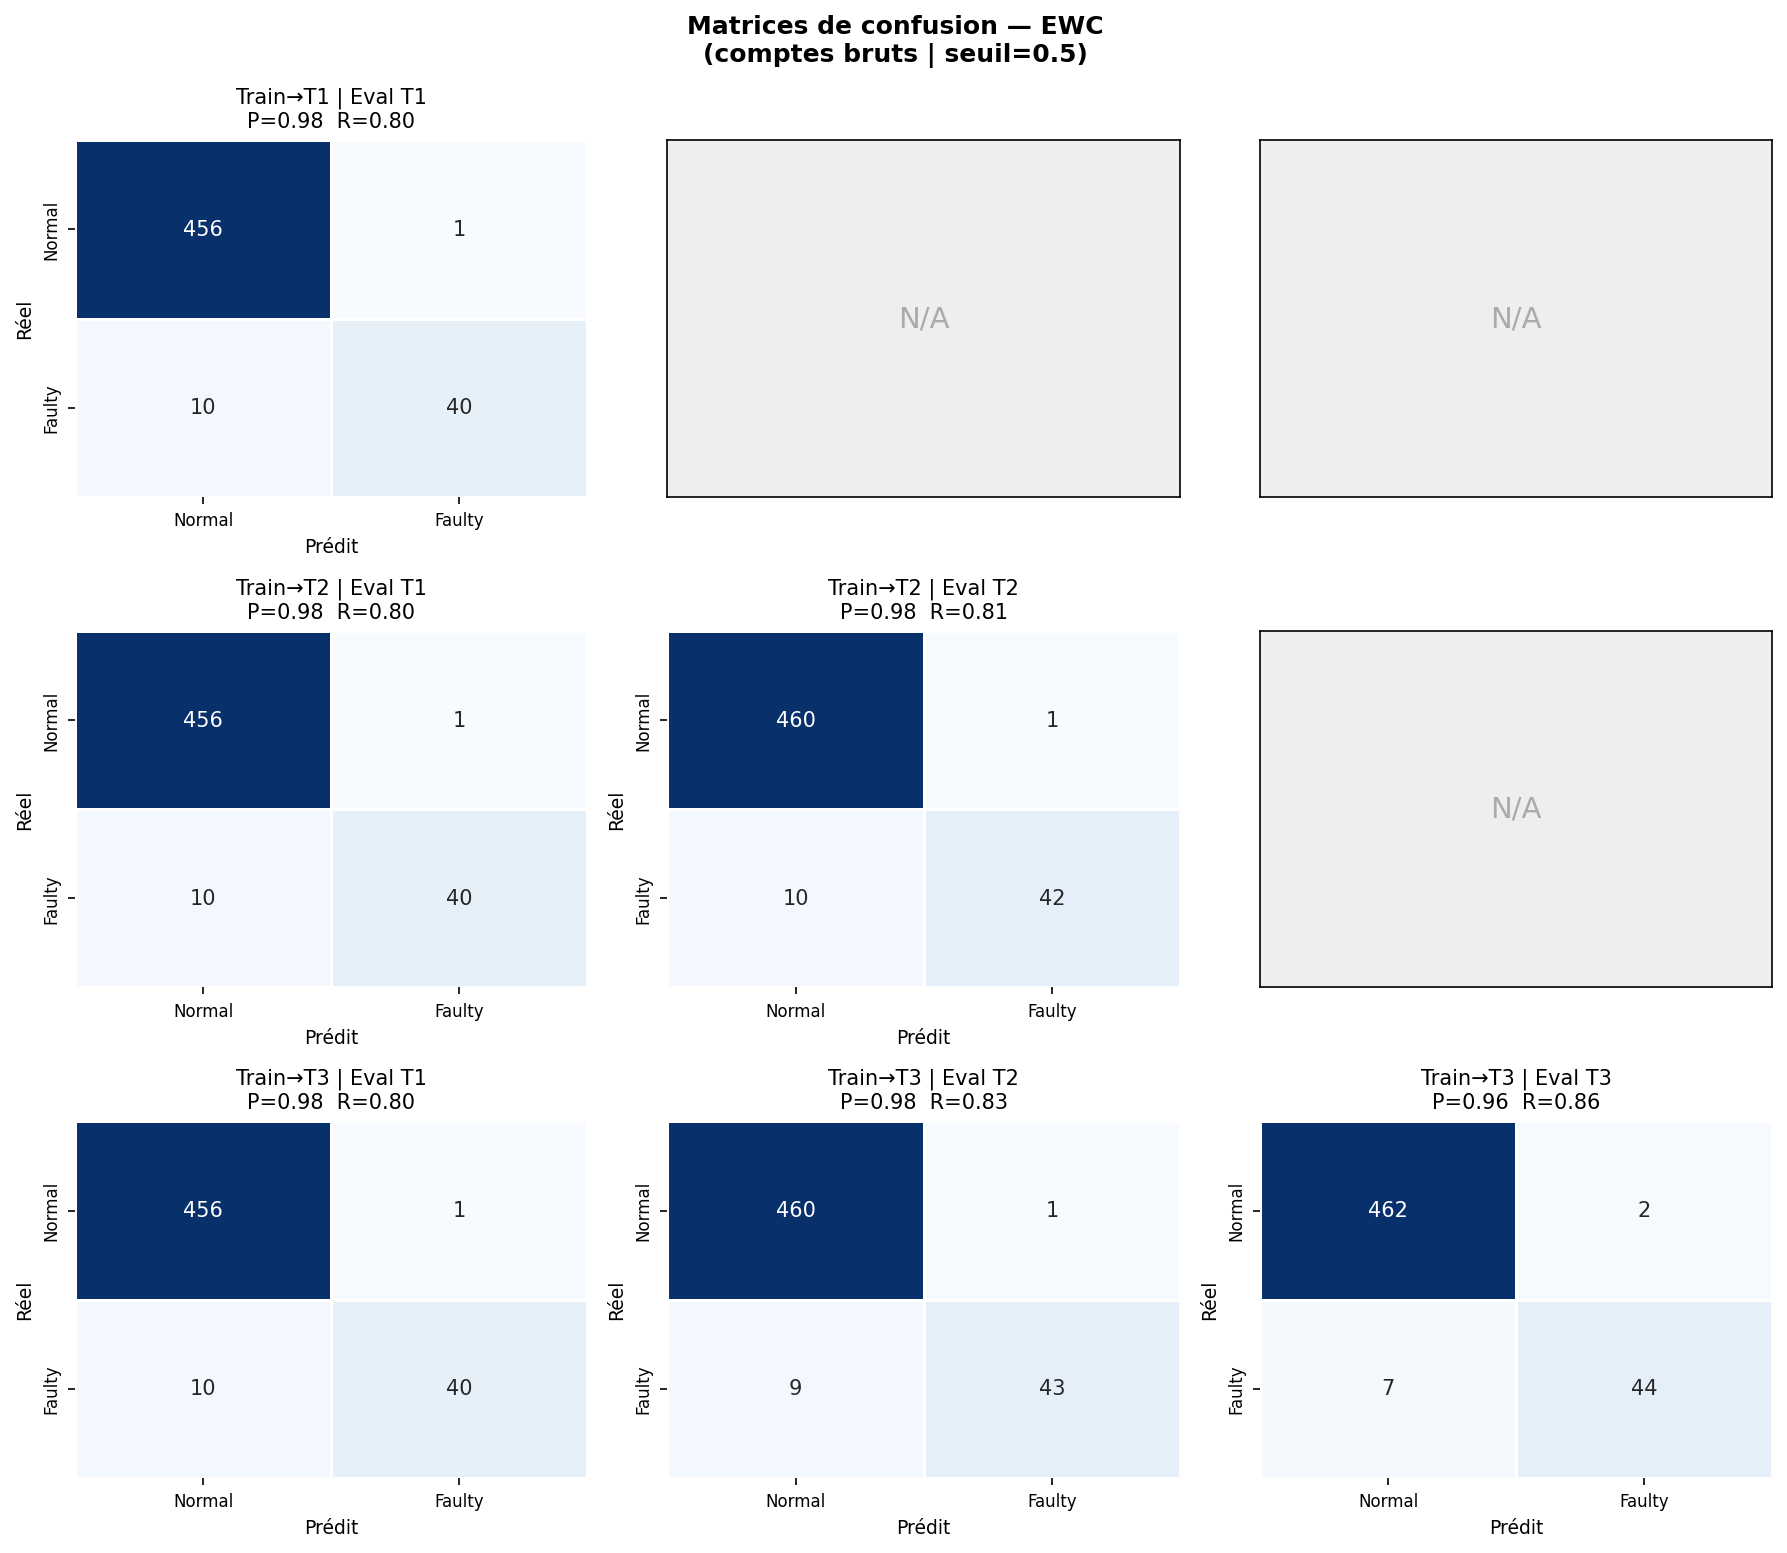

In [7]:
# Section 6B — Matrices de confusion par tâche (grille 3×3) — comptes bruts
# Même grille que 6A mais sans normalisation : affiche les nombres absolus de prédictions
# Utile pour évaluer le déséquilibre de classes et les volumes réels par cellule

fig = plot_confusion_matrix_grid(
    preds_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
    threshold=0.5,
    normalize=False,
)
save_figure(fig, FIGURES_DIR / "confusion_matrix_grid_raw.png")
display(Image(str(FIGURES_DIR / "confusion_matrix_grid_raw.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/ewc/monitoring/by_equipment/roc_curves.png


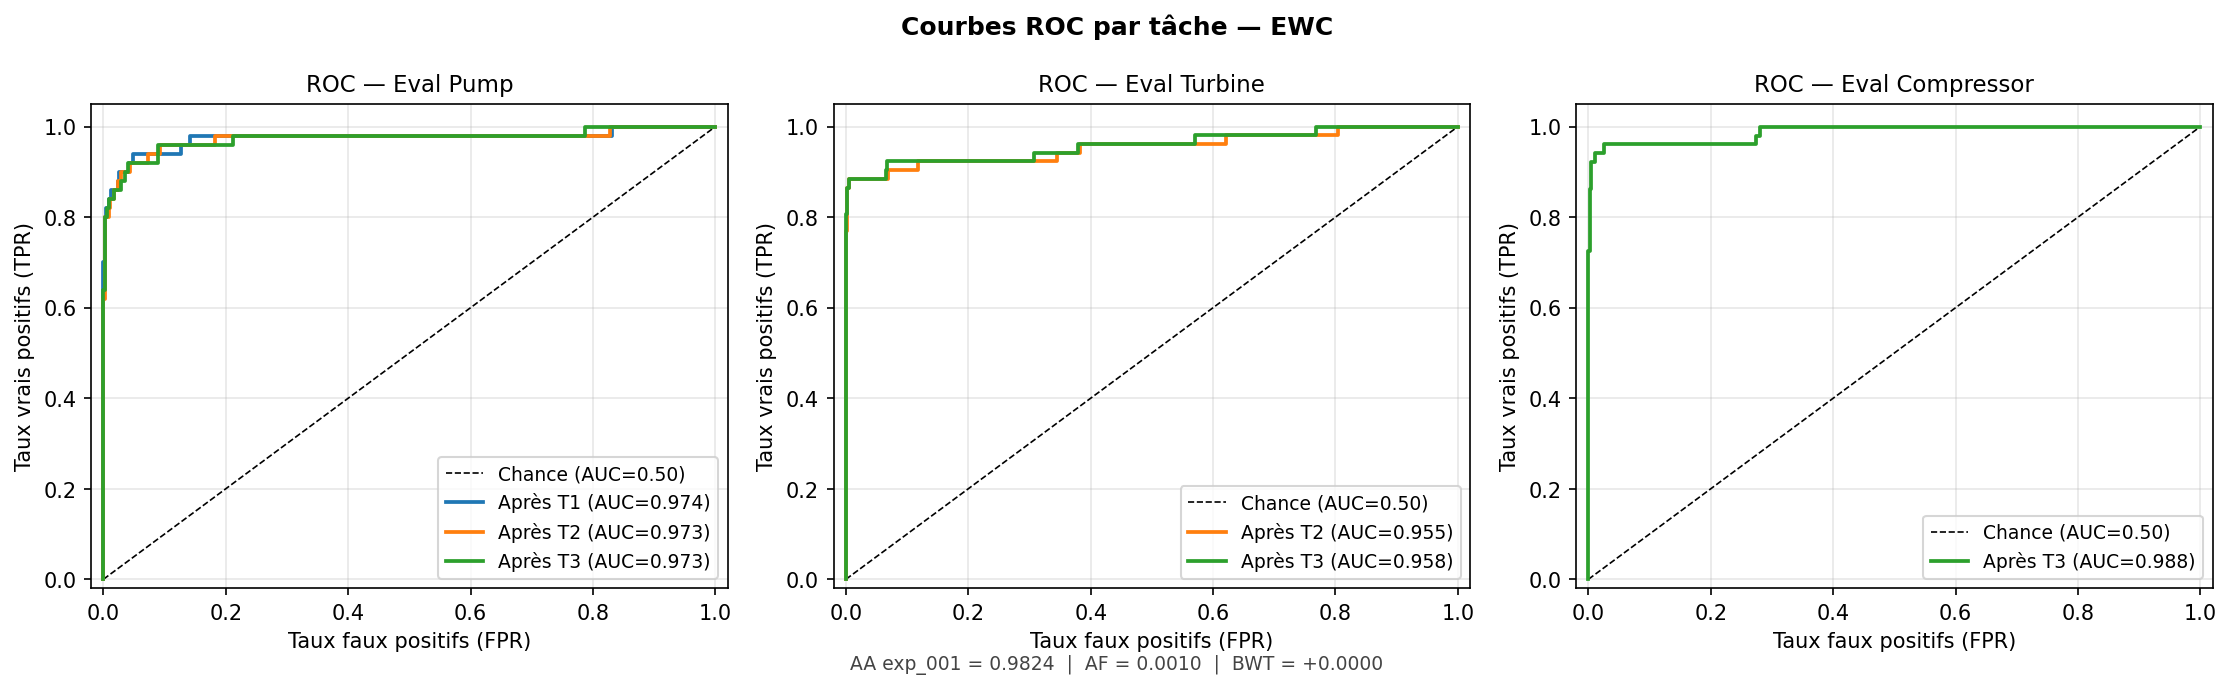

In [8]:
# Section 7 — Courbes ROC par tâche
# EWC est un classifieur supervisé → sorties sigmoid = scores de probabilité continus
# Une courbe par step d'entraînement sur chaque tâche j (courbes superposées)

fig = plot_roc_curves_per_task(
    preds_dict,
    scores_dict=proba_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
)

# Footer : AA final exp_001 pour référence
fig.text(
    0.5, 0.01,
    f"AA exp_001 = {cl['aa']:.4f}  |  AF = {cl['af']:.4f}  |  BWT = {cl['bwt']:+.4f}",
    ha="center", fontsize=9, color="#444444",
)

save_figure(fig, FIGURES_DIR / "roc_curves.png")
display(Image(str(FIGURES_DIR / "roc_curves.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/ewc/monitoring/by_equipment/feature_space_pca.png


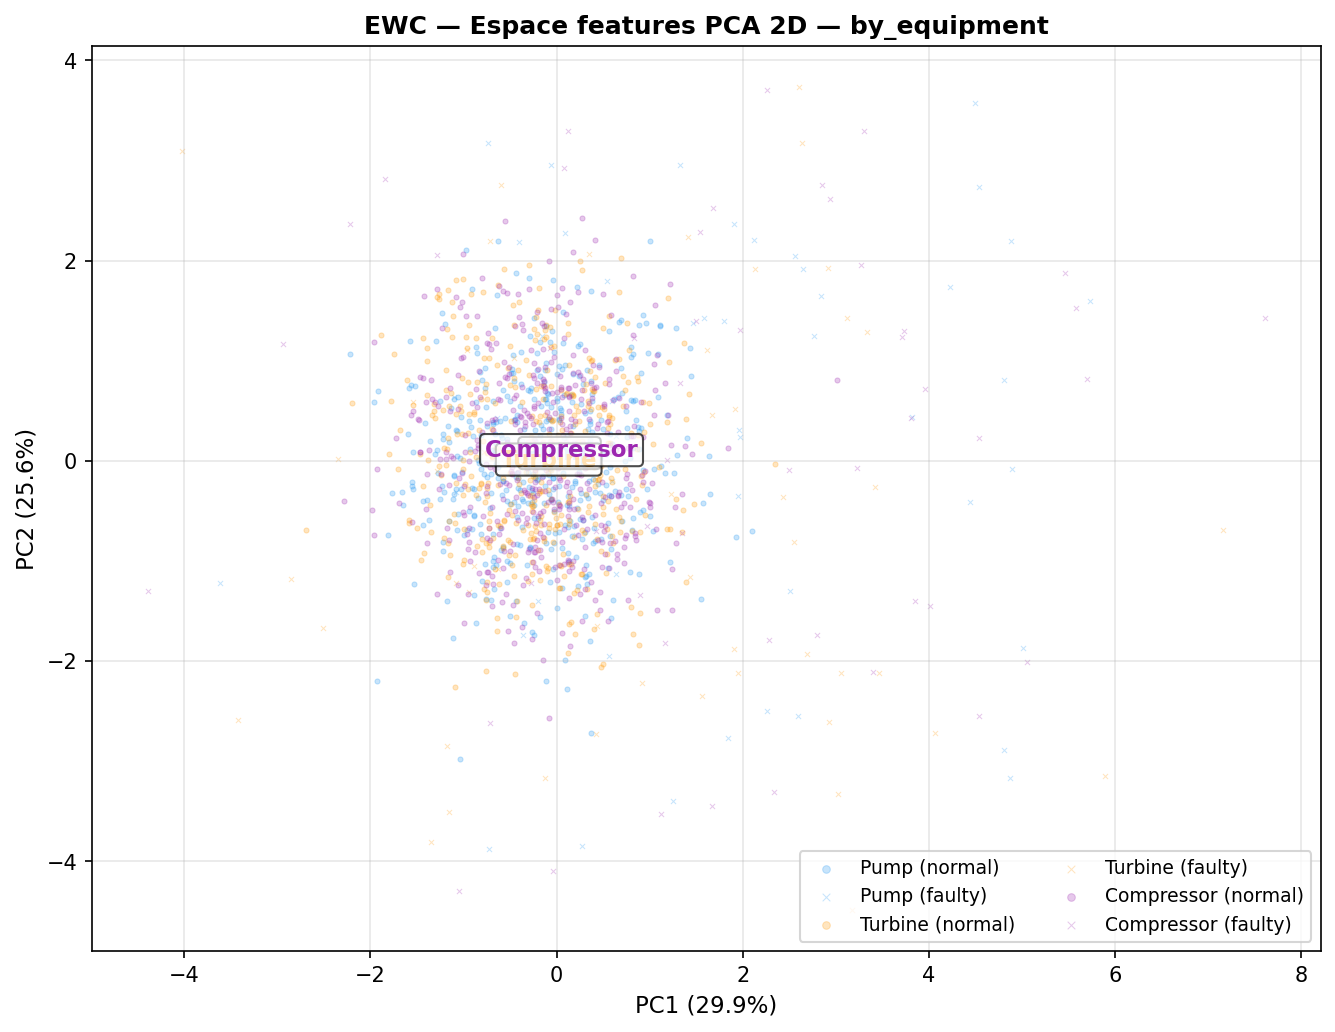

In [9]:
# Section 8 — Espace des features (PCA 2D)
# Visualise la distribution des 3 tâches dans l'espace 2D PCA
# Coloré par tâche (domain_ids) et par label (normal/faulty)
# Permet de vérifier la séparabilité inter-tâches et la cohérence du modèle

if DATA_AVAILABLE and len(X_tests_raw) == 3:
    # Concaténer toutes les données de validation
    X_all      = np.concatenate(X_tests_raw, axis=0)   # [N_total, 4]
    y_all      = np.concatenate(y_tests_raw, axis=0)   # [N_total]
    domain_ids = np.concatenate([
        np.full(len(X_tests_raw[k]), k) for k in range(3)
    ])  # [N_total]

    # Projection PCA 2D globale
    pca, X_proj = fit_pca2d(X_all)
    expl_var = pca.explained_variance_ratio_
    xlabel = f"PC1 ({expl_var[0]*100:.1f}%)"
    ylabel = f"PC2 ({expl_var[1]*100:.1f}%)"

    fig, ax = plt.subplots(figsize=(9, 7))

    plot_feature_space_2d(
        X_proj, y_all,
        title=f"{MODEL_NAME} — Espace features PCA 2D — by_equipment",
        ax=ax,
        domain_ids=domain_ids,
        alpha=0.25,
        s=6,
        xlabel=xlabel,
        ylabel=ylabel,
    )

    # Annoter les centroïdes par tâche
    TASK_COLORS = ["#2196F3", "#FF9800", "#9C27B0"]
    for k, (name, color) in enumerate(zip(TASK_NAMES, TASK_COLORS)):
        mask = domain_ids == k
        cx, cy = X_proj[mask, 0].mean(), X_proj[mask, 1].mean()
        ax.annotate(
            name,
            xy=(cx, cy),
            fontsize=11,
            fontweight="bold",
            color=color,
            ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        )

    fig.tight_layout()
    save_figure(fig, FIGURES_DIR / "feature_space_pca.png")
    display(Image(str(FIGURES_DIR / "feature_space_pca.png")))

else:
    display(Markdown(
        "> ⚠️ **Section 8 ignorée** — CSV absent ou scénario CL non rejoué. "
        "feature_space_pca.png non généré."
    ))
    print("[SKIP] feature_space_pca.png — données non disponibles.")

In [10]:
# Section 9 — Tableau récapitulatif + critères d'acceptation

aa    = cl["aa"]
af    = cl["af"]
bwt   = cl["bwt"]
ram_b = mem["ram_peak_bytes"]
ram_ko = ram_b / 1024
lat   = mem["inference_latency_ms"]
n_par = mem["n_params"]
forgetting_per_task = cl.get("forgetting_per_task", [])

display(Markdown("### Résultats finaux — EWC Online + MLP — monitoring/by_equipment (exp_001)"))

recap_table = f"""
| Modèle | AA ↑ | AF ↓ | BWT | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|-------|-----------|----------|
| {MODEL_NAME} | {aa:.4f} | {af:.4f} | {bwt:+.4f} | {ram_ko:.2f} Ko | {lat:.5f} ms | {n_par} |
"""
display(Markdown(recap_table))

print(f"Forgetting par tâche (Pump, Turbine) : {[round(v, 4) for v in forgetting_per_task]}")
print()
print("=" * 60)
print("  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)")
print("=" * 60)
print(f"  RAM = {ram_b} B = {ram_ko:.2f} Ko")
print(f"  Budget STM32N6 : 65 536 B (64 Ko)")
print(f"  Marge disponible : {65536 - ram_b} B ({(65536 - ram_b)/1024:.1f} Ko)")
print(f"  EWC occupe {ram_b / 65536 * 100:.2f}% du budget RAM")
print()
print("=" * 60)
print("  NOTE SCIENTIFIQUE — Gap 3 (pas de replay → 0 mémoire données)")
print("=" * 60)
print(f"  EWC λ=1000 protège contre l'oubli via la diagonale de Fisher")
print(f"  Aucun buffer de replay nécessaire (contrainte online STM32N6)")
print(f"  État EWC (Fisher + θ*) = 2 × {n_par} × 4B = {2 * n_par * 4} B supplémentaires")
print(f"  Total EWC incl. état = {ram_b + 2 * n_par * 4} B ({(ram_b + 2*n_par*4)/1024:.2f} Ko)")
print()
print("  FIXME(gap2) : Documenter la marge RAM pour la pénalité Fisher dans le manuscrit.")
print("  TODO(arnaud) : Les matrices Fisher diag sont-elles sauvegardées dans les checkpoints ?")
print()

# Vérification des critères d'acceptation
print("=" * 60)
print("  Critères d'acceptation (S7-02)")
print("=" * 60)
for fig_name in ["acc_matrix.png", "forgetting_curve.png", "confusion_matrix_grid.png",
                 "roc_curves.png", "feature_space_pca.png"]:
    status = "OK" if (FIGURES_DIR / fig_name).exists() else "MANQUANTE"
    print(f"  [{status}] {fig_name}")

print()
print(f"  [{'OK' if abs(aa - 0.9824) < 0.005 else 'WARN'}] AA     = {aa:.4f}  (attendu ≈ 0.9824)")
print(f"  [{'OK' if abs(af - 0.0010) < 0.001 else 'WARN'}] AF     = {af:.4f}  (attendu ≈ 0.0010)")
print(f"  [{'OK' if abs(bwt) < 0.005 else 'WARN'}] BWT    = {bwt:+.4f} (attendu ≈ 0.0000)")
print(f"  [{'OK' if ram_b <= 65536 else 'FAIL'}] RAM    = {ram_ko:.2f} Ko (contrainte ≤ 64 Ko)")
print(f"  [{'OK' if lat < 100.0 else 'WARN'}] Latence= {lat:.5f} ms (contrainte ≤ 100 ms)")

### Résultats finaux — EWC Online + MLP — monitoring/by_equipment (exp_001)


| Modèle | AA ↑ | AF ↓ | BWT | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|-------|-----------|----------|
| EWC | 0.9824 | 0.0010 | +0.0000 | 1.14 Ko | 0.03580 ms | 705 |


Forgetting par tâche (Pump, Turbine) : [0.0, 0.0019]

  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)
  RAM = 1171 B = 1.14 Ko
  Budget STM32N6 : 65 536 B (64 Ko)
  Marge disponible : 64365 B (62.9 Ko)
  EWC occupe 1.79% du budget RAM

  NOTE SCIENTIFIQUE — Gap 3 (pas de replay → 0 mémoire données)
  EWC λ=1000 protège contre l'oubli via la diagonale de Fisher
  Aucun buffer de replay nécessaire (contrainte online STM32N6)
  État EWC (Fisher + θ*) = 2 × 705 × 4B = 5640 B supplémentaires
  Total EWC incl. état = 6811 B (6.65 Ko)

  FIXME(gap2) : Documenter la marge RAM pour la pénalité Fisher dans le manuscrit.
  TODO(arnaud) : Les matrices Fisher diag sont-elles sauvegardées dans les checkpoints ?

  Critères d'acceptation (S7-02)
  [OK] acc_matrix.png
  [OK] forgetting_curve.png
  [OK] confusion_matrix_grid.png
  [OK] roc_curves.png
  [OK] feature_space_pca.png

  [OK] AA     = 0.9824  (attendu ≈ 0.9824)
  [OK] AF     = 0.0010  (attendu ≈ 0.0010)
  [OK] BWT    = +0.0000 (at